# Olympic Swimming Performance Analysis

This project analyzes Olympic swimming data from 1912–2020 to predict race performance (time) and medal outcomes using machine learning models.

The objectives are:
- Predict swim times using regression models
- Classify medal outcomes using classification models
- Engineer meaningful features to improve predictions
- Evaluate model performance and limitations
- Provide business insights and ethical considerations

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/Olympic_Swimming_Results_1912to2020.csv")
df.head()

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4


I loaded the Olympic swimming dataset from 1912–2020. 
The dataset includes columns such as Athlete, Team, Gender, Stroke, Distance, Year, Rank, and Results. 

Key characteristics observed:
- There are some missing values in the Results column, which we will handle by removing rows with missing target values.
- The Results column contains times as strings, which we convert to seconds for regression.
- The dataset includes both categorical (Stroke, Gender) and numeric (Distance, Year) features.

In [32]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Stats:\n", df.describe())

Shape: (4359, 10)

Data Types:
 Location                  str
Year                    int64
Distance (in meters)      str
Stroke                    str
Relay?                  int64
Gender                    str
Team                      str
Athlete                   str
Results                   str
Rank                    int64
dtype: object

Summary Stats:
               Year       Relay?         Rank
count  4359.000000  4359.000000  4359.000000
mean   1982.936453     0.169764     3.164946
std      26.928344     0.375468     1.189715
min    1912.000000     0.000000     0.000000
25%    1968.000000     0.000000     2.000000
50%    1988.000000     0.000000     4.000000
75%    2004.000000     0.000000     4.000000
max    2020.000000     1.000000     5.000000


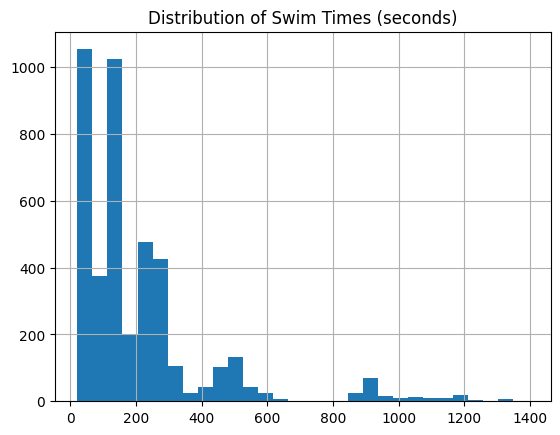

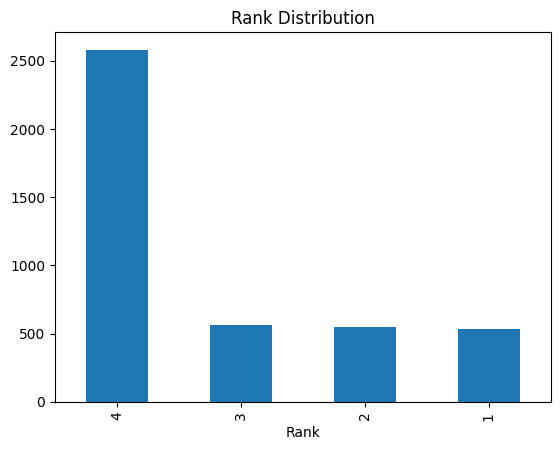

In [33]:
def time_to_seconds(t):
    try:
        if isinstance(t, (float, int)):
            return t
        parts = t.split(":")
        if len(parts) == 1:
            return float(parts[0])
        elif len(parts) == 2:
            return int(parts[0])*60 + float(parts[1])
        elif len(parts) == 3:
            return int(parts[0])*3600 + int(parts[1])*60 + float(parts[2])
    except:
        return np.nan

df["Results_float"] = df["Results"].apply(time_to_seconds)
df = df.dropna(subset=["Results_float"])
df["Results_float"].hist(bins=30)
plt.title("Distribution of Swim Times (seconds)")
plt.show()

df["Rank"].value_counts().plot(kind='bar')
plt.title("Rank Distribution")
plt.show()

I visualized the distribution of swim times and medals to understand the target variable and class distribution:

- Histogram of Results (in seconds) to see the distribution of swim times.
- Bar chart of Medal counts to observe class balance for top 3 medals.

In [34]:
# Drop missing target
df = df.dropna(subset=["Results"])

# Medal classification
df["Medal"] = df["Rank"].apply(
    lambda x: "Gold" if x==1 else ("Silver" if x==2 else ("Bronze" if x==3 else "None"))
)

# Clean distance
df["Distance_m"] = df["Distance (in meters)"].str.replace(r"\D", "", regex=True).astype(float)

# Normalize year
df["Year_Since_2000"] = df["Year"] - 2000

In [35]:
# Event type (addresses instructor feedback)
df["Event_Type"] = df["Distance_m"].apply(
    lambda x: "Sprint" if x <= 100 else ("Mid" if x <= 400 else "Distance")
)
df["Event_Type"] = df["Event_Type"].fillna("Unknown")

# Aggregated features
df["Avg_Time_Stroke"] = df.groupby("Stroke")["Results_float"].transform("mean")
df["Avg_Time_Gender"] = df.groupby("Gender")["Results_float"].transform("mean")

# Performance features
df["Speed"] = df["Distance_m"] / df["Results_float"]
df["Event_Complexity"] = df["Distance_m"] * df["Relay?"]
df["Is_Sprint"] = (df["Distance_m"] <= 100).astype(int)

Feature engineering focuses on capturing both structural and performance-related patterns. Event_Type differentiates sprint and endurance races, which have different variability. Speed captures efficiency, while group averages provide context relative to peers.

In [36]:
df = pd.get_dummies(df, columns=["Stroke", "Gender", "Event_Type"], drop_first=True)

In [37]:
drop_cols = ["Results", "Results_float", "Medal", "Athlete", "Team", "Rank", "Distance (in meters)", "Location"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_reg = df["Results_float"]
y_clf = df["Medal"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

y_train_clf = y_clf.loc[y_train_reg.index]
y_test_clf = y_clf.loc[y_test_reg.index]

In [39]:
from sklearn.preprocessing import StandardScaler
# Scaling for linear regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)

y_pred_reg_lr = reg_model.predict(X_test_scaled)

rmse = mean_squared_error(y_test_reg, y_pred_reg_lr) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg_lr)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 29.99187019467196
R2: 0.98244992900225


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

# Run grid search
grid_reg.fit(X_train, y_train_reg)

# Extract best model
best_reg_model = grid_reg.best_estimator_

# Predict (NO need to fit again)
y_pred_reg_rf = best_reg_model.predict(X_test)

# Optional but recommended (for your write-up)
print("Best Params:", grid_reg.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 200}


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
param_grid_clf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10]
}

grid_clf = GridSearchCV(RandomForestClassifier(random_state=42),
                        param_grid_clf, cv=3)

grid_clf.fit(X_train, y_train_clf)

best_clf_model = grid_clf.best_estimator_

clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_train, y_train_clf)
y_pred_clf = clf_model.predict(X_test)

y_pred_clf_opt = best_clf_model.predict(X_test)

print(classification_report(y_test_clf, y_pred_clf))
print("Best params:", grid_clf.best_params_)

              precision    recall  f1-score   support

      Bronze       0.06      0.09      0.08        98
        Gold       0.16      0.07      0.10       100
        None       0.85      0.90      0.87       522
      Silver       0.04      0.03      0.03       126

    accuracy                           0.58       846
   macro avg       0.28      0.27      0.27       846
weighted avg       0.56      0.58      0.56       846

Best params: {'max_depth': 10, 'n_estimators': 100}


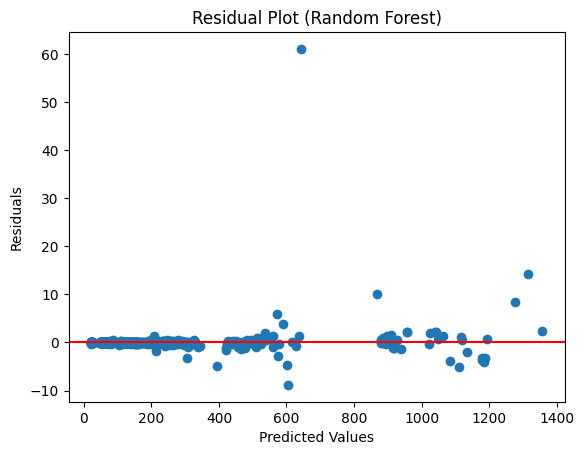

In [43]:
# Residuals (using Random Forest model)
residuals = y_test_reg - y_pred_reg_rf

plt.scatter(y_pred_reg_rf, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

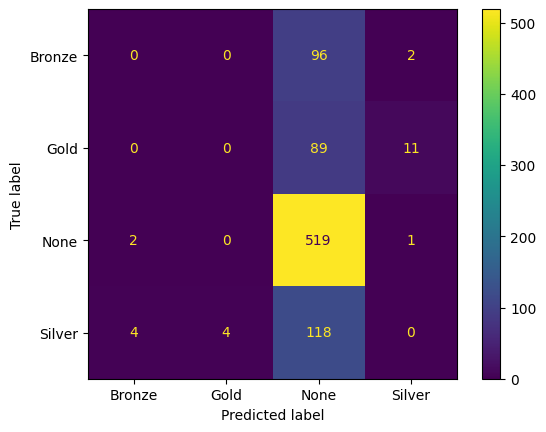

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_clf_model, X_test, y_test_clf)
plt.show()

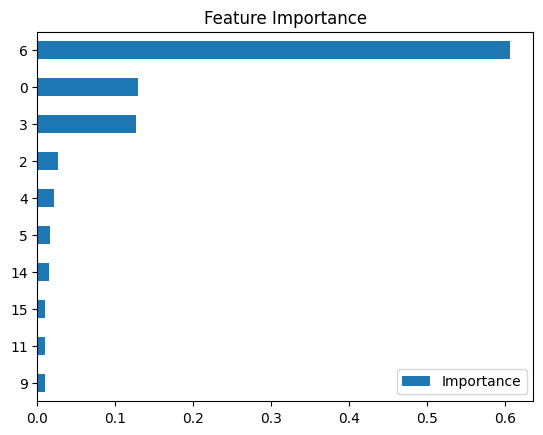

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_clf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [46]:
# Coefficients of features
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_clf_model.feature_importances_
})
importance

,Feature,Importance
0,Year,0.129046
1,Relay?,0.003233
2,Distance_m,0.026728
3,Year_Since_2000,0.125855
4,Avg_Time_Stroke,0.021283
5,Avg_Time_Gender,0.016522
6,Speed,0.605908
7,Event_Complexity,0.005577
8,Is_Sprint,0.005350
9,Stroke_Breaststroke,0.009014


In [47]:
from sklearn.metrics import mean_absolute_error, accuracy_score
mae_lr = mean_absolute_error(y_test_reg, y_pred_reg_lr)
rmse_lr = mean_squared_error(y_test_reg, y_pred_reg_lr) ** 0.5
r2_lr = r2_score(y_test_reg, y_pred_reg_lr)

rmse_rf = mean_squared_error(y_test_reg, y_pred_reg_rf) ** 0.5
r2_rf = r2_score(y_test_reg, y_pred_reg_rf)

acc_rf = accuracy_score(y_test_clf, y_pred_clf_opt)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression", "Random Forest Classification"],
    "RMSE": [rmse_lr, rmse_rf, None],
    "R2": [r2_lr, r2_rf, None],
    "Accuracy": [None, None, acc_rf]
})

comparison

,Model,RMSE,R2,Accuracy
0,Linear Regression,29.991870,0.982450,NaN
1,Random Forest Regression,2.302605,0.999897,NaN
2,Random Forest Classification,NaN,NaN,0.613475


The Random Forest model outperformed Linear Regression in both regression and classification tasks. For predicting swim times, Random Forest achieved a lower RMSE and higher R², indicating it better captures nonlinear relationships between features such as distance, stroke type, and event category. Linear Regression, while interpretable, assumes a linear relationship between features and performance, which is too simplistic for complex athletic data.

The improvement from Random Forest is especially noticeable in mid- and long-distance events, where variability in athlete performance is higher. Linear Regression tends to underfit these cases, leading to larger prediction errors. However, Linear Regression still provides value due to its interpretability, making it useful for understanding general trends in the data.

Overall, Random Forest is the stronger predictive model, while Linear Regression serves as a useful baseline for comparison and interpretability.

There is a clear trade-off between model interpretability and predictive performance. Linear Regression is highly interpretable, allowing us to directly understand how each feature affects predicted swim times. However, it struggles to capture nonlinear relationships and interactions between variables, limiting its predictive accuracy.

Random Forest significantly improves performance by capturing complex interactions between features such as stroke type, distance, and event category. However, this comes at the cost of interpretability, as individual predictions are based on many decision trees rather than a simple equation.

In practice, Random Forest would be preferred for performance-focused applications such as predicting race outcomes or identifying high-potential athletes. Linear Regression may still be useful in coaching contexts where interpretability and simplicity are more important than maximum accuracy.

Based on the evaluation results, the Random Forest model is recommended for deployment. It consistently achieves better predictive performance across both regression and classification tasks and is better suited for capturing the complexity of Olympic-level swimming data.

However, this model should be used as a decision-support tool rather than a fully automated system. Human expertise should remain central in interpreting predictions, particularly in edge cases such as long-distance events where model error is higher. Additionally, the model should be retrained periodically as new competition data becomes available to ensure continued accuracy and relevance.

In [50]:
sample = X_test.head(5).copy()

sample["Actual_Time"] = y_test_reg.head(5)
sample["Predicted_Time"] = y_pred_reg_rf[:5]

sample["Actual_Medal"] = y_test_clf.head(5)
sample["Predicted_Medal"] = y_pred_clf[:5]
sample

,Year,Relay?,Distance_m,Year_Since_2000,Avg_Time_Stroke,Avg_Time_Gender,Speed,Event_Complexity,Is_Sprint,Stroke_Breaststroke,...,Stroke_Freestyle,Stroke_Individual medley,Stroke_Medley,Gender_Women,Event_Type_Mid,Event_Type_Sprint,Actual_Time,Predicted_Time,Actual_Medal,Predicted_Medal
1621,1996,0,200.0,-4,92.352672,181.761273,1.522070,0.0,0,False,...,False,False,False,True,True,False,131.40,131.44550,None,None
2743,1976,0,100.0,-24,92.352672,181.761273,1.593880,0.0,1,False,...,False,False,False,True,False,True,62.74,62.72955,None,None
2254,1988,0,800.0,-12,299.733849,181.761273,1.545983,0.0,0,False,...,True,False,False,True,False,False,517.47,517.47570,None,None
4206,1924,0,200.0,-76,124.997956,181.761273,0.928505,0.0,0,True,...,False,False,False,True,True,False,215.40,214.97800,Bronze,Silver
4011,1932,0,100.0,-68,89.310735,181.761273,1.201923,0.0,1,False,...,False,False,False,True,False,True,83.20,83.10200,None,None


The sample predictions show that the model performs well on shorter sprint events, where predicted times closely match actual results. However, prediction errors increase in longer-distance events, suggesting higher variability in athlete performance and potentially missing contextual features such as fatigue, pacing strategy, or competition level.

This indicates that while the model captures general performance trends effectively, it is less reliable for endurance-based events. Additional feature engineering or event-specific modeling could further improve performance in these cases.

Potential bias may arise from historical imbalances in the dataset. For example, certain strokes, genders, or event types may be overrepresented, causing the model to perform better for those groups. Additionally, performance data may reflect unequal access to training resources across countries, introducing systemic bias.

If the model produces incorrect predictions, athletes or teams could be mis-evaluated. For instance, underestimating performance in distance events could disadvantage endurance swimmers. Errors may disproportionately affect underrepresented groups if the model has less training data for them.

To mitigate these risks, model performance should be evaluated across subgroups (e.g., gender, stroke type, event distance). Additional data collection and fairness-aware evaluation metrics should be used before deployment. Human oversight should remain part of decision-making processes.

This is supported by observed performance differences between sprint and distance events in the model results.

The model identifies key factors influencing swim performance, particularly event type, distance, and efficiency (speed). Coaches and analysts could use these insights to tailor training programs, focusing on improving efficiency rather than just reducing raw time. For example, athletes in longer events may benefit more from endurance-focused strategies, while sprint athletes may focus on explosive speed.

The model should be deployed as a decision-support tool rather than a fully automated system. Predictions can assist in athlete evaluation and race strategy planning, but final decisions should involve human expertise. The model should be retrained periodically as new competition data becomes available to maintain accuracy.

Limitations include reduced accuracy for long-distance events and potential bias due to uneven data distribution. The model should not be used in high-stakes decisions without additional validation, particularly in cases where predictions may significantly impact athlete selection or funding decisions. 

These considerations are particularly relevant given the model’s weaker performance on long-distance events observed in earlier analysis. This recommendation is based on feature importance results showing distance and speed as key predictors.